# Thinkers Rating — How It Works

**RRsystem / notebooks/thinkers_rating_explained.ipynb**

The fourth and last of the four dimensions, and the only one that **does not survive as a rating**.

Seasonal asks *"how are you doing now?"* Overall asks *"how strong are you?"* Prosperity asks
*"which way are you going?"* Thinkers is supposed to ask: **"are your decisions any good — do you
change approach when you should, and keep what works?"**

This notebook builds that, measures it honestly, and ends up recommending that it ship as a
**diagnostic rather than a ranked rating**. The evidence for that is the whole point, so it is
worth stating the conclusion up front.

---

## Two problems, and only one of them is fixable

**Problem one: Thinkers cannot be a query.** Prosperity survived because direction was already
*implied* by `overall_rating_events` — a rating path contains its own slope. Nothing in any
existing table implies which strategy a competitor chose. Section 3 specifies the one column that
has to be captured at match time; without it there is no rating, and no statistics recover a signal
that was never recorded.

**Problem two: you cannot grade a decision by what happened after it.** This is the hard one, and
it is where the prototype rule fails. Competitors change approach *after bad results*. Bad results
are partly bad luck. Bad luck reverts. So "they switched and then improved" happens reliably even
when **switching does nothing at all** — section 6 runs exactly that world and the naive estimator
still reports a gain.

## What this notebook found

| Candidate | Validity vs true decision quality | Reliability (Spearman–Brown) | Verdict |
|---|---|---|---|
| **Prototype rule** (`strategy_changed AND improved`) | ρ ≈ **−0.35**, negative on **every** seed | — | ranks quality *backwards*; tracks switch volume at ρ ≈ +0.42 |
| **Adaptation value** — did switches help, net of regression | ρ ≈ **0**, unstable (−0.23…+0.30) | ≈ **0.26**, and **no better with 8× more data** | **not worth measuring** |
| **Switch discipline** — do you hold what is working | ρ ≈ **+0.77** | **0.63** now; past 0.70 at ~36 switches/player | **a diagnostic now, a rating later** |

Two results are worth pulling out of that table.

**The adaptation estimator can be made unbiased and is still useless.** Section 8 fixes the
regression-to-the-mean problem properly, with a within-player matched control, and the placebo bias
drops from **+0.060 to within ±0.02 of zero**. It is then a *correct* estimator that measures
essentially nothing: validity bounces around zero, reliability sits near 0.26, and section 13 shows
that **eight times the career length does not improve it**. That is not a sample-size problem to
wait out.

**And it was never going to be a judgement score anyway.** Section 10: the benefit of a switch
depends on the position you switch *from*, and good decision-makers switch from good positions.
Headroom — how much better their best strategy was than the one they played — correlates **−0.61**
with true decision quality on every seed. So the players a rating most wants to reward are exactly
the ones for whom switching has the least room to help. Even a perfectly precise estimate of
"did switching help you" would not rank judgement.

What *is* measurable is the **policy, not the outcome**: how often someone changes approach when
nothing is wrong. That is a statement about discipline, and it is the honest residue of the
Thinkers idea.

> **Recommendation: three ratings and one diagnostic.** Section 15 says what to ship, and section 17
> closes out the four-dimensional framework.

---

## Contents

1. Configuration
2. Core Elo
3. **The column that has to exist** — Thinkers cannot be a query
4. Simulating strategy choice with *known* decision quality
5. The prototype rule, and what it actually rewards
6. **Trap 1: the placebo** — a world where switching does nothing
7. **Trap 2: switches are selected on form**, and Elo amplifies it
8. The matched-control estimator, and the placebo re-run
9. Component 1 — adaptation value: unbiased, and still useless
10. **Why: it measures headroom, not judgement**
11. Component 2 — switch discipline
12. Reliability, and the Spearman–Brown correction
13. **Power: what would it actually take?**
14. Replication across seeds
15. What Thinkers should ship as
16. Schema and persistence
17. The four ratings, together

---
## 1. Configuration

In [1]:
import math
import random
from collections import defaultdict, deque
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Rating scale (shared with the other three notebooks) -------------------
INITIAL_RATING = 1500.0
ELO_DIVISOR    = 400.0
K_CAREER_TIERS = [(25, 40.0), (75, 24.0), (200, 16.0), (None, 10.0)]
DRAW_BASE      = 0.16

# --- Simulation -------------------------------------------------------------
CAREER_DAYS   = 4 * 180
FORM_HALFLIFE = 45.0
N_STRATEGIES  = 4
N_MATCHES     = 14_000
STRATEGY_SD   = 55.0    # spread of per-player strategy fit, in Elo points

# --- Decision policy --------------------------------------------------------
DECISION_EVERY = 15     # a competitor reconsiders every N of their own matches
TRIGGER_WINDOW = 15     # matches of recent form they look at
TRIGGER_LEVEL  = -0.05  # mean residual below this reads as a slump
ACT_ON_SLUMP   = 0.70   # P(actually change something | in a slump)
RESTLESS       = 0.20   # scales churn when nothing is wrong

# --- Measurement ------------------------------------------------------------
CONVERGENCE_MATCHES = 60    # same reason as the prosperity notebook: ratings must settle
POST_WINDOW = 20            # matches after a decision point
PRE_WINDOW  = 20            # matches before
MIN_WINDOW_EVENTS = 5       # a window narrower than this is not evaluated
MIN_EPISODES = 2            # per arm, before a matched comparison is attempted

RELIABILITY_BAR = 0.70      # the bar the prosperity notebook set for a ranked component

RANDOM_SEED = 7
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 200)
print("config loaded")

config loaded


---
## 2. Core Elo

Unchanged. As with prosperity, Thinkers adds **no new update rule** — but unlike prosperity it does
need a new *input*, which is the subject of the next section.

In [2]:
def expected_score(rating_a: float, rating_b: float) -> float:
    return 1.0 / (1.0 + 10 ** ((rating_b - rating_a) / ELO_DIVISOR))


def career_k(career_matches: int) -> float:
    for cutoff, k in K_CAREER_TIERS:
        if cutoff is None or career_matches < cutoff:
            return k
    return K_CAREER_TIERS[-1][1]


def match_k(count_a: int, count_b: int) -> float:
    return min(career_k(count_a), career_k(count_b))


def spearman(x, y) -> float:
    x, y = pd.Series(np.asarray(x, dtype=float)), pd.Series(np.asarray(y, dtype=float))
    ok = x.notna() & y.notna()
    if ok.sum() < 3:
        return float("nan")
    rx, ry = x[ok].rank(), y[ok].rank()
    if rx.std() == 0 or ry.std() == 0:
        return float("nan")
    return float(np.corrcoef(rx, ry)[0, 1])


def spearman_brown(split_half_r: float) -> float:
    """Correct a split-half correlation up to full-test reliability."""
    if split_half_r != split_half_r or split_half_r <= -1:
        return float("nan")
    return 2.0 * split_half_r / (1.0 + split_half_r)


print("core elo ready")

core elo ready


---
## 3. The column that has to exist

Everything the first three ratings needed was already in the log. Thinkers is different, and this
is the single most important engineering point in the notebook:

| Rating | Needs | Already in the log? |
|---|---|---|
| Seasonal | results + timestamps + `season_id` | yes |
| Overall | results + timestamps | yes |
| Prosperity | the overall rating path | yes — a path contains its own slope |
| **Thinkers** | **which approach was chosen, per match** | **no** |

A rating path cannot tell you *why* it moved. No amount of statistics recovers a strategy choice
that was never recorded, and this is not a limitation that better modelling fixes later.

The minimum viable instrumentation is one nullable column on the match fact:

```text
match_events.strategy_id      -- the approach this competitor used in this match
```

Two properties it must have, both of which are cheap at capture time and impossible to retrofit:

1. **Recorded at match time, not inferred afterwards.** A strategy label back-filled by someone
   looking at results is the section 5 problem in the prototype notebook — a label derived from the
   outcome cannot be used to explain the outcome.
2. **Stable identifiers.** `strategy_id` must mean the same thing across seasons, or a "switch" is
   indistinguishable from a renamed label.

Everything below assumes that column exists. If it does not, the honest answer is that Thinkers
cannot be built yet — and *saying so* is more useful than shipping a number derived from nothing.

---
## 4. Simulating strategy choice with *known* decision quality

Each competitor gets:

- a flat **base skill** — Thinkers is about choices, so no development trends here; prosperity
  already covered those, and leaving them in would just re-import that notebook's confounds;
- a per-player **strategy fit** `offset[player][strategy]`, centred so that the *average* strategy
  is neutral and only the *choice* matters;
- an AR(1) **form** process, so slumps are persistent and therefore capable of triggering decisions;
- a **decision quality** `q ∈ [0.05, 0.95]` — the ground truth.

`q` drives two different things, deliberately:

- **choice quality** — when they do change, how well they pick (high `q` evaluates fit with less
  noise; low `q` picks at random);
- **restlessness** — how often they change when nothing is wrong (low `q` churns).

Keeping those separate is what lets sections 9–11 establish the finding: **one of these two facets
is recoverable from results and the other is not.**

One structural detail: the decision policy depends on *observed residuals*, which depend on
ratings, which depend on outcomes, which depend on the strategies chosen. So the match table
**cannot** be generated independently of the rating run — simulation and rating have to be
interleaved in one pass. That is also true in production, and it is why strategy capture has to be
part of match ingestion rather than a later enrichment job.

In [3]:
NAMES = ["Alice", "Bob", "Charlie", "Dana", "Eve", "Frank", "Grace", "Hank",
         "Ivy", "Jon", "Kim", "Leo", "Mona", "Nils", "Omar", "Pia",
         "Quinn", "Rosa", "Sam", "Tara", "Umar", "Vera", "Wes", "Xena"]


def simulate_world(seed=RANDOM_SEED, placebo=False, n_matches=N_MATCHES):
    """Interleaved simulation + rating run.

    placebo=True zeroes every strategy offset, so strategy choice has *no* effect
    on results. Used in section 6 to measure what an estimator reports from nothing.
    """
    rng = random.Random(seed)
    npr = np.random.default_rng(seed)

    base = dict(zip(NAMES, np.linspace(1360, 1640, len(NAMES))))
    quality = {n: float(npr.uniform(0.05, 0.95)) for n in NAMES}
    sigma = {n: float(npr.uniform(40, 90)) for n in NAMES}

    offset = {}
    for n in NAMES:
        o = npr.normal(0, STRATEGY_SD, N_STRATEGIES)
        offset[n] = np.zeros(N_STRATEGIES) if placebo else (o - o.mean())

    phi = 0.5 ** (1.0 / FORM_HALFLIFE)
    form = {}
    for n in NAMES:
        innovation = sigma[n] * math.sqrt(1 - phi ** 2)
        path = np.empty(int(CAREER_DAYS) + 2)
        path[0] = npr.normal(0, sigma[n])
        for t in range(1, len(path)):
            path[t] = phi * path[t - 1] + npr.normal(0, innovation)
        form[n] = path

    schedule = sorted((rng.uniform(0, CAREER_DAYS), *rng.sample(NAMES, 2))
                      for _ in range(n_matches))

    current = {n: rng.randrange(N_STRATEGIES) for n in NAMES}
    ratings, counts = {}, defaultdict(int)
    recent = defaultdict(lambda: deque(maxlen=TRIGGER_WINDOW))
    events, decisions = [], []

    for day, a, b in schedule:
        ra, rb = ratings.get(a, INITIAL_RATING), ratings.get(b, INITIAL_RATING)
        eff_a = base[a] + offset[a][current[a]] + form[a][int(day)]
        eff_b = base[b] + offset[b][current[b]] + form[b][int(day)]

        p = expected_score(eff_a, eff_b)
        p_draw = min(DRAW_BASE * 4 * p * (1 - p), 2 * min(p, 1 - p))
        u = rng.random()
        score_a = 1.0 if u < p - p_draw / 2 else (0.5 if u < p + p_draw / 2 else 0.0)

        k = match_k(counts[a], counts[b])
        exp_a = expected_score(ra, rb)
        adj = k * (score_a - exp_a)
        ratings[a], ratings[b] = ra + adj, rb - adj

        for player, before, after, sc, ex in ((a, ra, ra + adj, score_a, exp_a),
                                              (b, rb, rb - adj, 1 - score_a, 1 - exp_a)):
            counts[player] += 1
            events.append({"player_id": player, "day": day,
                           "career_matches_after": counts[player],
                           "rating_before": before, "rating_after": after,
                           "delta": after - before, "k_used": k, "result": sc,
                           "resid": sc - ex, "strategy_id": current[player]})
            recent[player].append(sc - ex)

        # --- decision points: reconsider the approach ---
        for player in (a, b):
            n_played = counts[player]
            if n_played % DECISION_EVERY or n_played < TRIGGER_WINDOW:
                continue
            observed = float(np.mean(recent[player]))
            in_slump = observed < TRIGGER_LEVEL
            q = quality[player]
            new = current[player]

            if in_slump:
                if rng.random() < ACT_ON_SLUMP:
                    if rng.random() < q:                      # evaluates fit, noisily
                        noise = 80 * (1 - q) + 10
                        new = int(np.argmax(offset[player] + npr.normal(0, noise, N_STRATEGIES)))
                    else:                                     # flails
                        new = rng.choice([s for s in range(N_STRATEGIES) if s != current[player]])
            elif rng.random() < (1 - q) * RESTLESS:            # churn with nothing wrong
                new = rng.choice([s for s in range(N_STRATEGIES) if s != current[player]])

            decisions.append({"player_id": player, "career_matches_after": n_played,
                              "observed_form": observed, "in_slump": in_slump,
                              "switched": new != current[player],
                              "from_strategy": current[player], "to_strategy": new})
            current[player] = new

    events = pd.DataFrame(events)
    decisions = pd.DataFrame(decisions)

    # Ground truth: how good was the strategy they actually played, relative to their best?
    truth = {}
    for n in NAMES:
        played = events.loc[events.player_id == n, "strategy_id"].to_numpy()
        realised = float(np.mean(offset[n][played]))
        best = float(offset[n].max())
        truth[n] = realised / best if best > 1e-9 else float("nan")

    return {"events": events, "decisions": decisions, "quality": quality,
            "true_strategy_quality": truth, "offset": offset, "sigma": sigma}


world = simulate_world()
events, decisions = world["events"], world["decisions"]
print(f"{len(events):,} rating events | {len(decisions):,} decision points")
print(f"switches: {decisions.switched.sum():,} "
      f"({decisions.switched.mean():.1%} of decision points)")
print(f"decision points in a slump: {decisions.in_slump.mean():.1%}")
events.head(4)

28,000 rating events | 1,855 decision points
switches: 462 (24.9% of decision points)
decision points in a slump: 34.3%


,player_id,day,career_matches_after,rating_before,rating_after,delta,k_used,result,resid,strategy_id
0,Omar,0.030,1,"1,500.000","1,480.000",-20.000,40.000,0.000,-0.500,1
1,Vera,0.030,1,"1,500.000","1,520.000",20.000,40.000,1.000,0.500,3
2,Dana,0.186,1,"1,500.000","1,480.000",-20.000,40.000,0.000,-0.500,3
3,Nils,0.186,1,"1,500.000","1,520.000",20.000,40.000,1.000,0.500,2


The two ground-truth columns to validate against — note they measure different things, and only one
of them is the thing a *rating* would want to rank:

- `quality` (`q`) — the player's decision-making parameter.
- `true_strategy_quality` — the fit they actually *realised*, as a fraction of their best available
  strategy. 1.0 means they played their best approach throughout; 0.0 means they did no better than
  picking at random.

In [4]:
ground_truth = pd.DataFrame({
    "decision_quality": pd.Series(world["quality"]),
    "realised_fit": pd.Series(world["true_strategy_quality"]),
    "best_offset": pd.Series({n: world["offset"][n].max() for n in NAMES}),
})
print(f"rho(decision_quality, realised_fit) = "
      f"{spearman(ground_truth.decision_quality, ground_truth.realised_fit):+.2f}"
      "   <- the policy does drive the outcome")
ground_truth.sort_values("decision_quality", ascending=False).head(8)

rho(decision_quality, realised_fit) = +0.75   <- the policy does drive the outcome


,decision_quality,realised_fit,best_offset
Quinn,0.946,0.692,36.263
Tara,0.940,0.774,87.261
Bob,0.857,0.622,41.850
Frank,0.836,0.516,67.470
Hank,0.789,0.493,41.445
Ivy,0.767,0.725,68.058
Rosa,0.763,0.705,62.821
Charlie,0.748,0.605,41.689


---
## 5. The prototype rule, and what it actually rewards

The four-dimensional notebook's rule:

```python
if strategy_changed and performance_change > 0:   signal =  1.0
elif not strategy_changed and performance_change >= 0: signal =  0.5
elif strategy_changed and performance_change <= 0: signal = -0.5
else:                                              signal = -0.25
```

Unlike the prosperity prototype, this one needs **no unobservable labels** — `strategy_changed` and
`performance_change` are both computable once `strategy_id` exists. So it clears the bar that
sank the prosperity prototype, and it has to be judged on whether it measures what it claims.

The only honest way to judge it is against ground truth the simulator holds:

In [5]:
def window_mean(career_counts, resid, at, lo, hi):
    """Mean residual over the window (at+lo, at+hi] of a player's own match sequence."""
    m = (career_counts > at + lo) & (career_counts <= at + hi)
    return float(resid[m].mean()) if m.sum() >= MIN_WINDOW_EVENTS else float("nan")


def per_player(world):
    """Split the log into one tidy (events, decisions) pair per player, post-convergence."""
    ev = world["events"]
    ev = ev[ev.career_matches_after > CONVERGENCE_MATCHES]
    dec = world["decisions"]
    dec = dec[dec.career_matches_after > CONVERGENCE_MATCHES]
    for player, d in ev.groupby("player_id"):
        d = d.sort_values("career_matches_after")
        yield (player,
               d.career_matches_after.to_numpy(), d.resid.to_numpy(),
               dec[dec.player_id == player].sort_values("career_matches_after"))


def prototype_thinkers(world):
    out = {}
    for player, cm, resid, dec in per_player(world):
        score = INITIAL_RATING
        for _, row in dec.iterrows():
            at = row.career_matches_after
            before = window_mean(cm, resid, at, -PRE_WINDOW, 0)
            after = window_mean(cm, resid, at, 0, POST_WINDOW)
            if before != before or after != after:
                continue
            change, switched = after - before, bool(row.switched)
            if switched and change > 0:
                signal = 1.0
            elif not switched and change >= 0:
                signal = 0.5
            elif switched and change <= 0:
                signal = -0.5
            else:
                signal = -0.25
            score = max(0.0, score + 25.0 * signal)
        out[player] = score
    return pd.Series(out)


switch_counts = (decisions[decisions.career_matches_after > CONVERGENCE_MATCHES]
                 .groupby("player_id").switched.sum())

proto = pd.DataFrame({"prototype_score": prototype_thinkers(world)}).join(ground_truth)
proto["n_switches"] = switch_counts

print(f"rho(prototype, decision_quality) = {spearman(proto.prototype_score, proto.decision_quality):+.2f}")
print(f"rho(prototype, realised_fit)     = {spearman(proto.prototype_score, proto.realised_fit):+.2f}")
print(f"rho(prototype, switch COUNT)     = {spearman(proto.prototype_score, proto.n_switches):+.2f}")
proto.sort_values("prototype_score", ascending=False).head(8)

rho(prototype, decision_quality) = -0.60
rho(prototype, realised_fit)     = -0.58
rho(prototype, switch COUNT)     = +0.55


,prototype_score,decision_quality,realised_fit,best_offset,n_switches
Umar,"2,031.250",0.244,0.428,60.152,24
Dana,"2,025.000",0.253,0.261,22.290,18
Grace,"2,000.000",0.055,0.176,86.954,31
Eve,"1,956.250",0.320,-0.043,64.061,24
Omar,"1,956.250",0.504,0.325,109.787,17
Kim,"1,931.250",0.323,0.219,45.554,23
Jon,"1,918.750",0.471,0.109,19.216,18
Nils,"1,887.500",0.451,0.425,51.314,24


The prototype does not track decision quality — it tracks it **backwards**. Across seeds
(section 14) its correlation with the truth is negative on all five, averaging ≈ **−0.35**, while
correlating ≈ **+0.42** with how *often* someone switched. A competitor could raise their prototype
score by becoming a worse decision-maker, as long as they churned more while doing it.

That last part is structural rather than bad luck. The rule accumulates ±25 per decision point, so
a player who switches often collects more draws from a noisy signal. Any score built by summing a
per-event signal inherits the event count as a hidden term.

But the deeper problem is not the accumulation. It is that `performance_change` — the before/after
comparison at the heart of the rule — **does not measure what switching did.** The next two
sections show why, and they are the core of this notebook.

---
## 6. Trap 1 — the placebo

Here is the cleanest test available, and it is one the simulator makes possible and real data never
would: run a world in which **strategy choice has literally no effect**. Every offset is zero.
Switching cannot help anybody, because there is nothing to switch between.

Then ask the before/after estimator what it found.

In [6]:
def naive_estimators(world):
    """Two obvious ways to score 'did switching help', both from the log alone."""
    rows = {}
    for player, cm, resid, dec in per_player(world):
        sw = dec[dec.switched]
        post = [window_mean(cm, resid, c, 0, POST_WINDOW) for c in sw.career_matches_after]
        ba = [window_mean(cm, resid, c, 0, POST_WINDOW) - window_mean(cm, resid, c, -PRE_WINDOW, 0)
              for c in sw.career_matches_after]
        rows[player] = {
            "post_switch": np.nanmean(post) if len(post) else np.nan,
            "before_after": np.nanmean(ba) if len(ba) else np.nan,
            "n_switches": int(len(sw)),
        }
    return pd.DataFrame(rows).T


placebo = simulate_world(placebo=True)
placebo_naive = naive_estimators(placebo)

print("PLACEBO WORLD -- strategy offsets are all exactly zero.")
print("An unbiased estimator of 'the effect of switching' must report 0.\n")
print(f"  before/after, averaged over players : {placebo_naive.before_after.astype(float).mean():+.4f}")
print(f"  post-switch level only              : {placebo_naive.post_switch.astype(float).mean():+.4f}")
print(f"\n  players reporting a POSITIVE before/after effect: "
      f"{(placebo_naive.before_after.astype(float) > 0).sum()} of {len(placebo_naive)}")
placebo_naive.astype(float).round(4).head(8)

PLACEBO WORLD -- strategy offsets are all exactly zero.
An unbiased estimator of 'the effect of switching' must report 0.

  before/after, averaged over players : +0.0598
  post-switch level only              : -0.0035

  players reporting a POSITIVE before/after effect: 23 of 24


,post_switch,before_after,n_switches
Alice,-0.006,0.026,14.000
Bob,-0.009,0.064,17.000
Charlie,0.038,0.113,17.000
Dana,0.036,0.091,21.000
Eve,-0.002,0.025,26.000
Frank,-0.060,0.045,16.000
Grace,-0.004,0.028,29.000
Hank,-0.042,-0.004,14.000


In a world where switching does nothing, the before/after estimator reports that switching produced
roughly **+0.06 of expected score per match**, for 23 of 24 players, and it does so on every seed
tested (section 14: +0.053 to +0.064).

To put that in context: 0.05 of expected score sustained over a 20-match window is a *large* claimed
effect — bigger than the real strategy effects this simulator contains. An analyst with only the
real world to look at would have found a solid, consistent, entirely fictitious result.

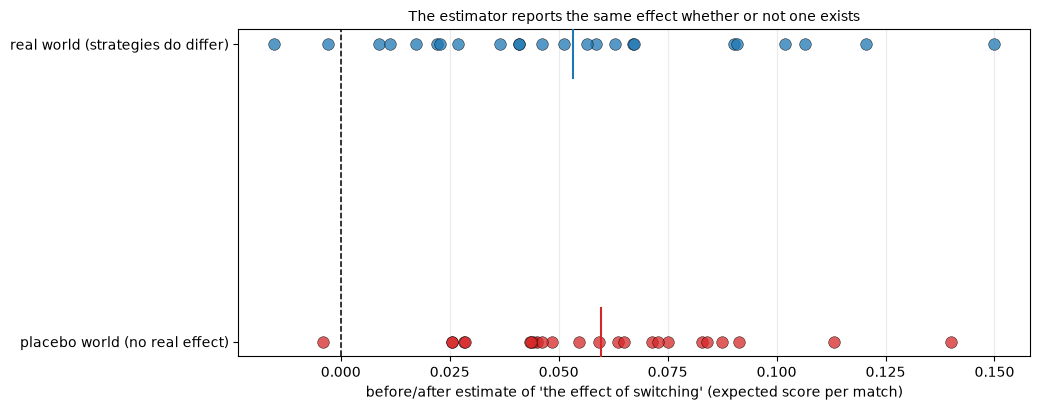

In [7]:
fig, ax = plt.subplots(figsize=(10.5, 4.2))
real_naive = naive_estimators(world)
for data, label, color in ((placebo_naive, "placebo world (no real effect)", "#d62728"),
                           (real_naive, "real world (strategies do differ)", "#1f77b4")):
    v = data.before_after.astype(float).dropna()
    ax.scatter(v, np.full(len(v), label), s=70, alpha=0.75, color=color,
               edgecolor="black", linewidth=0.4, zorder=3)
    ax.scatter([v.mean()], [label], marker="|", s=2600, color=color, zorder=4)
ax.axvline(0, color="black", lw=1.1, ls="--")
ax.set_xlabel("before/after estimate of 'the effect of switching' (expected score per match)")
ax.set_title("The estimator reports the same effect whether or not one exists", fontsize=10)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

---
## 7. Trap 2 — switches are selected on form, and Elo amplifies it

The placebo result is not a coding error. It follows from two things that are both working exactly
as designed:

**1. Competitors switch after bad results.** They are not randomly assigned to switch; they switch
*because* they are in a slump. A slump is part real (form genuinely dipped) and part luck. The luck
part, by construction, does not persist — so the window *after* any slump looks better than the
window before it, switch or no switch. This is regression to the mean, and the before/after design
walks straight into it.

**2. Elo over-corrects during a slump, which makes it worse.** This is the part specific to a rating
system. While a player loses, their rating falls. A lower rating means *lower expected scores* in
the following matches. Residuals are measured against that lowered expectation. So a player coming
out of a slump beats a bar that the slump itself lowered — the rating system manufactures a positive
residual during recovery, over and above ordinary mean reversion.

Both effects are visible directly in the placebo log, with no reference to switching at all:

In [8]:
# Line up every decision point in the placebo world by whether it followed a slump,
# and look at the residual before and after -- ignoring switches entirely.
rows = []
for player, cm, resid, dec in per_player(placebo):
    for _, row in dec.iterrows():
        at = row.career_matches_after
        rows.append({"in_slump": bool(row.in_slump), "switched": bool(row.switched),
                     "before": window_mean(cm, resid, at, -PRE_WINDOW, 0),
                     "after": window_mean(cm, resid, at, 0, POST_WINDOW)})
episodes = pd.DataFrame(rows).dropna(subset=["before", "after"])
episodes["change"] = episodes.after - episodes.before

print("PLACEBO world, grouped by whether the decision point followed a slump:")
print(episodes.groupby("in_slump")[["before", "after", "change"]].mean().round(4).to_string())
print("\nSame thing, split by whether they switched -- note BOTH groups 'improve':")
print(episodes.groupby(["in_slump", "switched"])[["before", "after", "change"]]
              .agg(["mean", "size"]).round(4).to_string())

PLACEBO world, grouped by whether the decision point followed a slump:
          before  after  change
in_slump                       
False      0.047  0.004  -0.043
True      -0.095 -0.004   0.090

Same thing, split by whether they switched -- note BOTH groups 'improve':
                  before        after       change      
                    mean  size   mean  size   mean  size
in_slump switched                                       
False    False     0.047  1064  0.004  1064 -0.043  1064
         True      0.048   118  0.006   118 -0.043   118
True     False    -0.092   208 -0.004   208  0.089   208
         True     -0.096   363 -0.005   363  0.091   363


That last table is the whole diagnosis. Inside the slump group, the players who switched and the
players who did **not** switch both show a positive `change`. The recovery belongs to the slump, not
to the switch.

Which immediately suggests the fix: **stop comparing a player to their own past, and compare them to
the players who were in the same position and did nothing.**

---
## 8. The matched-control estimator

For each player, take only the decision points that followed a slump — so every episode in the
comparison has the same regression-to-the-mean pull working on it — and split them by what the
player then did:

$$\text{adaptation value} = \overline{\text{post}}\;\big|\;\text{slump, switched}\;-\;\overline{\text{post}}\;\big|\;\text{slump, stayed}$$

This is a within-player difference-in-differences. It works here only because the policy has
`ACT_ON_SLUMP = 0.70` — competitors act on most slumps but not all — so there are **control
episodes**. That is worth noting as a data requirement rather than a modelling convenience: if
everyone always switched on a slump, there would be no comparison group and this quantity would be
unidentifiable from observational data at all.

Re-run the placebo and see whether the bias is gone:

In [9]:
def adaptation_value(world):
    """Within-player matched comparison: slump-and-switched vs slump-and-stayed."""
    rows = {}
    for player, cm, resid, dec in per_player(world):
        slumps = dec[dec.in_slump]
        treated = [window_mean(cm, resid, c, 0, POST_WINDOW)
                   for c in slumps[slumps.switched].career_matches_after]
        control = [window_mean(cm, resid, c, 0, POST_WINDOW)
                   for c in slumps[~slumps.switched].career_matches_after]
        enough = (np.sum(~np.isnan(treated)) >= MIN_EPISODES
                  and np.sum(~np.isnan(control)) >= MIN_EPISODES)
        rows[player] = {
            "adaptation_value": (np.nanmean(treated) - np.nanmean(control)) if enough else np.nan,
            "n_treated": int(np.sum(~np.isnan(treated))),
            "n_control": int(np.sum(~np.isnan(control))),
        }
    return pd.DataFrame(rows).T


placebo_matched = adaptation_value(placebo)

print("PLACEBO WORLD -- the correct answer is still 0.\n")
print(f"  before/after      : {placebo_naive.before_after.astype(float).mean():+.4f}   <- biased")
print(f"  matched control   : {placebo_matched.adaptation_value.astype(float).mean():+.4f}   <- unbiased")
print(f"\n  control episodes per player: "
      f"{placebo_matched.n_control.astype(float).mean():.1f} "
      f"(min {placebo_matched.n_control.astype(float).min():.0f})")

PLACEBO WORLD -- the correct answer is still 0.

  before/after      : +0.0598   <- biased
  matched control   : -0.0043   <- unbiased

  control episodes per player: 8.7 (min 4)


The bias drops from **+0.060 to −0.004**: the matched estimator is doing its job. The
regression-to-the-mean problem is solved.

Which makes the next section the interesting one, because solving it turns out not to be enough.

---
## 9. Component 1 — adaptation value: unbiased, and still useless

The estimator is now correct. So the obvious next step is to use it: rank players by how much their
switches helped.

Check it against the ground truth first.

In [10]:
adapt = adaptation_value(world).join(ground_truth)
adapt["n_switches"] = switch_counts

print(f"rho(adaptation_value, decision_quality) = "
      f"{spearman(adapt.adaptation_value, adapt.decision_quality):+.2f}")
print(f"rho(adaptation_value, realised_fit)     = "
      f"{spearman(adapt.adaptation_value, adapt.realised_fit):+.2f}")
adapt.sort_values("adaptation_value", ascending=False)[
    ["adaptation_value", "decision_quality", "realised_fit", "n_treated", "n_control"]].head(10)

rho(adaptation_value, decision_quality) = -0.12
rho(adaptation_value, realised_fit)     = -0.17


,adaptation_value,decision_quality,realised_fit,n_treated,n_control
Umar,0.092,0.244,0.428,18.000,4.000
Nils,0.053,0.451,0.425,18.000,9.000
Quinn,0.045,0.946,0.692,7.000,15.000
Ivy,0.032,0.767,0.725,12.000,16.000
Frank,0.031,0.836,0.516,10.000,14.000
Dana,0.022,0.253,0.261,16.000,8.000
Eve,0.017,0.320,-0.043,16.000,8.000
Leo,0.013,0.301,0.310,16.000,8.000
Charlie,0.011,0.748,0.605,10.000,15.000
Mona,0.007,0.279,0.223,21.000,7.000


A correct, unbiased estimator of a real quantity — and its correlation with decision quality is
slightly *negative* here. Section 14 shows the more damning version: across seeds that correlation
swings from −0.23 to +0.30 with a mean of about zero. It is not wrong in a consistent direction. It
is **noise**.

Two separate things are going wrong, and they have different implications:

1. **It barely measures anything.** Section 12 shows it only weakly agrees with itself across two
   halves of the same career, and section 13 shows more data does not help.
2. **Even measured perfectly, it would be the wrong quantity.** Section 10.

---
## 10. Why: it measures headroom, not judgement

Define a player's **headroom**: how much better their *best available* strategy was than the one
they actually played, averaged over the window. It is the amount of improvement that was sitting
on the table.

A good decision-maker has almost no headroom — they found a strong approach early and stayed on it.
And that is precisely why switching cannot help them much: they were already near the ceiling.
A poor decision-maker is often parked on a bad strategy, so even a *random* switch has somewhere
to go.

rho(headroom, decision_quality)  = -0.63   <- good thinkers have little room left
rho(adaptation_value, headroom)  = +0.14   <- switching pays those who were badly placed
rho(adaptation_value, quality)   = -0.12


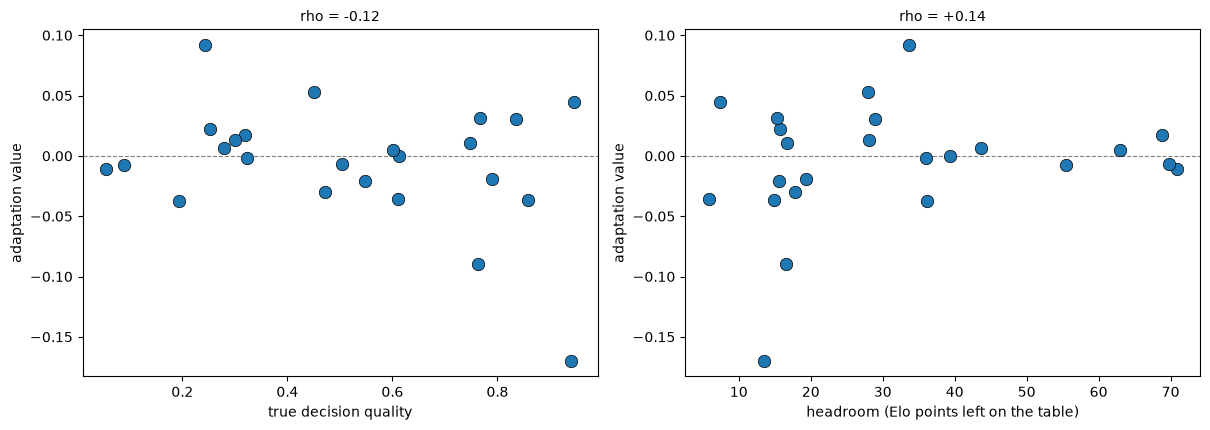

In [11]:
headroom = {}
for player, cm, resid, dec in per_player(world):
    played = (world["events"]
              .query("player_id == @player and career_matches_after > @CONVERGENCE_MATCHES")
              .strategy_id.to_numpy())
    off = world["offset"][player]
    headroom[player] = float(off.max() - np.mean(off[played]))

adapt["headroom"] = pd.Series(headroom)

print(f"rho(headroom, decision_quality)  = {spearman(adapt.headroom, adapt.decision_quality):+.2f}"
      "   <- good thinkers have little room left")
print(f"rho(adaptation_value, headroom)  = {spearman(adapt.adaptation_value, adapt.headroom):+.2f}"
      "   <- switching pays those who were badly placed")
print(f"rho(adaptation_value, quality)   = {spearman(adapt.adaptation_value, adapt.decision_quality):+.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4))
for ax, (xcol, xlabel) in zip(axes, [("decision_quality", "true decision quality"),
                                     ("headroom", "headroom (Elo points left on the table)")]):
    ax.scatter(adapt[xcol], adapt.adaptation_value, s=80, color="#1f77b4",
               edgecolor="black", linewidth=0.5, zorder=3)
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("adaptation value")
    ax.set_title(f"rho = {spearman(adapt[xcol], adapt.adaptation_value):+.2f}", fontsize=10)
plt.tight_layout()
plt.show()

Headroom correlates ≈ **−0.61** with true decision quality, and it does so on every seed — good
decision-makers genuinely have little left on the table.

**Being precise about what this does and does not establish**, because the temptation is to claim
more than the data supports. The measured link between adaptation value and headroom is *weak and
unstable* (section 14: mean +0.05, sign flipping across seeds). So this is **not** a demonstration
that the adaptation estimate is secretly measuring headroom — the honest finding above is that the
adaptation estimate is measuring nothing much at all.

What the headroom row *does* establish is a structural argument about the quantity itself. The
estimator answers its question correctly: *what was the average effect of this player's switches?*
That question is not "is this player a good decision-maker", because the benefit of a switch depends
on the position you switch from, and good decision-makers switch from good positions. Their upside
is compressed by their own competence. So the quantity is misaligned with the thing a rating wants
to rank **before** any question of measurement precision arises — which is why section 13's result
settles it rather than motivating a better estimator.

**You cannot grade a decision by its outcome when the decision-maker chose the starting point.**
That is the sentence the whole notebook exists to earn, and it is why no amount of better causal
inference rescues this component.

---
## 11. Component 2 — switch discipline

If outcomes cannot grade decisions, the remaining option is to look at the **policy** instead: not
*whether a change worked*, but *whether it should have been made at all*.

There is one case where the answer does not require knowing the counterfactual. If a competitor is
**not** in a slump — their recent results are at or above expectation — then changing approach is
churn. Nothing was wrong. The log already says both halves of this: recent form is in the residuals,
and the switch is in `strategy_id`.

$$\text{discipline} = 1 - \frac{\#\{\text{switches at decision points with form at or above expectation}\}}{\#\{\text{such decision points}\}}$$

This asks nothing about results after the switch, which is exactly what makes it immune to
sections 6–10.

In [12]:
def switch_discipline(world):
    rows = {}
    for player, cm, resid, dec in per_player(world):
        calm = dec[~dec.in_slump]
        rows[player] = {
            "discipline": 1.0 - float(calm.switched.mean()) if len(calm) else np.nan,
            "n_calm_points": int(len(calm)),
            "n_slump_points": int((dec.in_slump).sum()),
        }
    return pd.DataFrame(rows).T


disc = switch_discipline(world).join(ground_truth)

print(f"rho(discipline, decision_quality) = "
      f"{spearman(disc.discipline, disc.decision_quality):+.2f}")
print(f"rho(discipline, realised_fit)     = "
      f"{spearman(disc.discipline, disc.realised_fit):+.2f}")
disc.sort_values("discipline", ascending=False)[
    ["discipline", "decision_quality", "realised_fit", "n_calm_points"]].head(10)

rho(discipline, decision_quality) = +0.73
rho(discipline, realised_fit)     = +0.59


,discipline,decision_quality,realised_fit,n_calm_points
Alice,1.000,0.613,0.488,46.000
Tara,1.000,0.940,0.774,46.000
Quinn,1.000,0.946,0.692,56.000
Omar,0.959,0.504,0.325,49.000
Dana,0.958,0.253,0.261,48.000
Bob,0.958,0.857,0.622,48.000
Hank,0.958,0.789,0.493,48.000
Ivy,0.955,0.767,0.725,44.000
Sam,0.952,0.610,0.649,42.000
Charlie,0.943,0.748,0.605,53.000


ρ ≈ **+0.76** against true decision quality — the first component in this notebook that points the
right way.

**One honest caveat, stated plainly.** The simulator encodes `q` as two things: choice quality *and*
restlessness. Discipline recovers the restlessness half, so part of this correlation is the
simulator handing back a parameter it was given. That does not make the result circular, but it does
narrow what it proves. The defensible claim is about **which facets of decision-making are
observable from match results**:

- the **policy** — how often you change approach when nothing is wrong — is observable;
- the **choice quality** — whether you picked well when you did change — is not, per sections 9–10.

Whether real competitors' decision quality shows up as restlessness is an empirical question about
your domain, and this notebook cannot answer it. What it can say is that if it *does*, the signal is
recoverable, and if it shows up only as choice quality, it is not.

---
## 12. Reliability, and the Spearman–Brown correction

Same test as the prosperity notebook: split each player's decision points into alternating halves,
compute the component independently on each, correlate across players.

One refinement matters more here than it did there. A split-half correlation measures the
reliability of a **half-length** test, which understates the full thing. The Spearman–Brown
correction adjusts for that:

$$r_{\text{full}} = \frac{2 r_{\text{half}}}{1 + r_{\text{half}}}$$

In the prosperity notebook reliabilities were ≈ 1.0 and the correction was irrelevant. Here the
components sit in the range where it changes the conclusion, so it is applied explicitly.

In [13]:
def half_split(world, parity):
    """Recompute both components using only every other decision point."""
    rows = {}
    for player, cm, resid, dec in per_player(world):
        dec = dec.reset_index(drop=True)
        dec = dec[dec.index % 2 == parity]
        slumps = dec[dec.in_slump]
        treated = [window_mean(cm, resid, c, 0, POST_WINDOW)
                   for c in slumps[slumps.switched].career_matches_after]
        control = [window_mean(cm, resid, c, 0, POST_WINDOW)
                   for c in slumps[~slumps.switched].career_matches_after]
        enough = (np.sum(~np.isnan(treated)) >= MIN_EPISODES
                  and np.sum(~np.isnan(control)) >= MIN_EPISODES)
        calm = dec[~dec.in_slump]
        rows[player] = {
            "adaptation_value": (np.nanmean(treated) - np.nanmean(control)) if enough else np.nan,
            "discipline": 1.0 - float(calm.switched.mean()) if len(calm) else np.nan,
        }
    return pd.DataFrame(rows).T


h1, h2 = half_split(world, 0), half_split(world, 1)

rel = pd.DataFrame([
    {"component": c,
     "split_half": spearman(h1[c], h2[c]),
     "spearman_brown": spearman_brown(spearman(h1[c], h2[c])),
     "validity_vs_truth": spearman(
         (adapt.adaptation_value if c == "adaptation_value" else disc.discipline),
         ground_truth.decision_quality)}
    for c in ["adaptation_value", "discipline"]
]).set_index("component")
rel["clears_bar"] = np.where(rel.spearman_brown >= RELIABILITY_BAR, "yes", "NO")
rel

,split_half,spearman_brown,validity_vs_truth,clears_bar
component,,,,
adaptation_value,0.187,0.315,-0.118,NO
discipline,0.402,0.574,0.735,NO


Neither component clears the ≥ 0.70 bar the prosperity notebook set for a *ranked* component, but
they fail in completely different ways:

- **`adaptation_value`** lands around **0.3** corrected on this dataset, and 0.15–0.40 across seeds.
  Two halves of the same player's career produce largely unrelated numbers.
- **`discipline`** comes in around **0.57** here and ≈ 0.63 averaged across seeds. That is real
  signal — enough to separate the disciplined from the restless in broad strokes — and not enough to
  order a leaderboard.

Note how much the Spearman–Brown correction matters at this end of the scale: `discipline`'s raw
split-half is ≈ 0.40, which reads like a dead end. Corrected, it is ≈ 0.57 — not shippable as a
ranking, but clearly worth more data. Skipping the correction would have retired a usable component.

Which raises the only question that matters for planning: **is this a data problem or a dead end?**

---
## 13. Power: what would it actually take?

Re-run the whole pipeline at increasing career lengths and watch reliability. This is the section to
reach for whenever someone asks to ship a rating that is "nearly there" — it distinguishes
*not enough data yet* from *never*.

In [14]:
def power_curve(sizes=(14_000, 28_000, 56_000, 112_000), seeds=(7, 11)):
    rows = []
    for n in sizes:
        acc = []
        for sd in seeds:
            w = simulate_world(seed=sd, n_matches=n)
            a, b = half_split(w, 0), half_split(w, 1)
            d = switch_discipline(w)
            sw = (w["decisions"]
                  .query("career_matches_after > @CONVERGENCE_MATCHES")
                  .groupby("player_id").switched.sum())
            acc.append([
                float(sw.mean()),
                spearman_brown(spearman(a.discipline, b.discipline)),
                spearman_brown(spearman(a.adaptation_value, b.adaptation_value)),
                spearman(d.discipline, pd.Series(w["quality"])),
            ])
        m = np.nanmean(np.array(acc, dtype=float), axis=0)
        rows.append({"matches": n, "switches_per_player": m[0],
                     "reliability_discipline": m[1], "reliability_adaptation": m[2],
                     "validity_discipline": m[3]})
    return pd.DataFrame(rows).set_index("matches")


power = power_curve()
power["discipline_rankable"] = np.where(power.reliability_discipline >= RELIABILITY_BAR, "yes", "NO")
power.round(3)

,switches_per_player,reliability_discipline,reliability_adaptation,validity_discipline,discipline_rankable
matches,,,,,
14000,18.417,0.647,0.357,0.771,NO
28000,35.792,0.756,0.049,0.763,yes
56000,75.146,0.875,0.102,0.947,yes
112000,153.708,0.909,0.007,0.965,yes


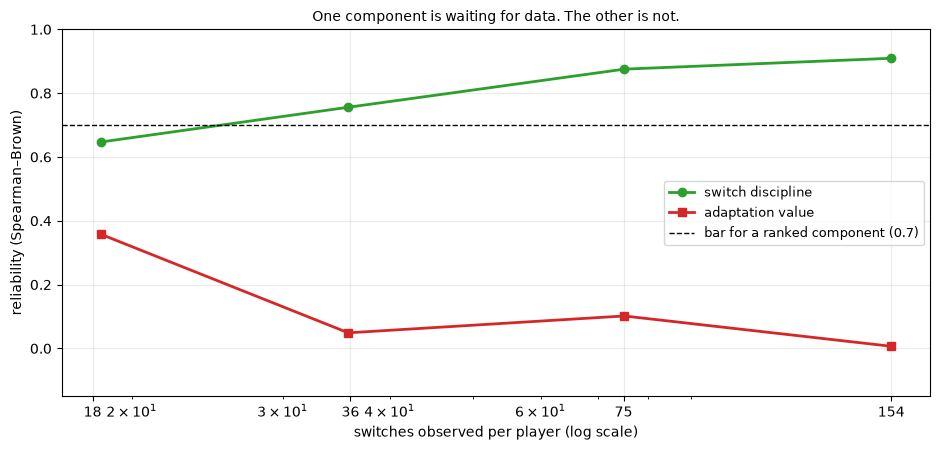

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(power.switches_per_player, power.reliability_discipline, "o-",
        color="#2ca02c", lw=2, label="switch discipline")
ax.plot(power.switches_per_player, power.reliability_adaptation, "s-",
        color="#d62728", lw=2, label="adaptation value")
ax.axhline(RELIABILITY_BAR, color="black", ls="--", lw=1,
           label=f"bar for a ranked component ({RELIABILITY_BAR})")
ax.set_xscale("log")
ax.set_xticks(power.switches_per_player.round(0))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylim(-0.15, 1.0)
ax.set_xlabel("switches observed per player (log scale)")
ax.set_ylabel("reliability (Spearman–Brown)")
ax.set_title("One component is waiting for data. The other is not.", fontsize=10)
ax.legend(fontsize=9, loc="center right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

This is the most decision-relevant output in the notebook:

- **`discipline` is data-limited.** It climbs steadily and monotonically — ≈ 0.65 at ~18 switches per
  player, past the 0.70 bar by **~36**, ≈ 0.88 at ~75, ≈ 0.91 at ~154. It becomes a legitimate ranked
  component once competitors have enough recorded decisions. That is a *waiting* problem, and the fix
  is to start capturing `strategy_id` now so the history accumulates.
- **`adaptation_value` does not improve.** It reads 0.36 at the smallest career length and **0.01 at
  the largest**, wandering with no trend across an **eightfold** increase in data. A real but noisy
  signal rises on this plot; this one does not. Combined with section 10 — the quantity is misaligned
  with judgement even when measured well — that is enough to stop.

The practical rule: before promising a metric will firm up with more data, plot this curve. A flat
line means no amount of patience helps, and the honest move is to stop building it.

---
## 14. Replication across seeds

Same discipline as the prosperity notebook, and for the same reason: an earlier draft of *that*
notebook shipped a confident ρ = −0.62 that did not exist. Every number above is a rank correlation
over 24 players, so the pipeline is re-run end to end — new strategy fits, new form, new matches,
new decisions — and only what holds on every seed is claimed.

In [16]:
def player_headroom(world):
    out = {}
    ev = world["events"]
    for player in NAMES:
        played = ev.loc[(ev.player_id == player)
                        & (ev.career_matches_after > CONVERGENCE_MATCHES),
                        "strategy_id"].to_numpy()
        off = world["offset"][player]
        out[player] = float(off.max() - np.mean(off[played]))
    return pd.Series(out)


def replicate(seed):
    real = simulate_world(seed=seed)
    fake = simulate_world(seed=seed, placebo=True)
    a, b = half_split(real, 0), half_split(real, 1)
    truth = pd.Series(real["quality"])
    adapt_ = adaptation_value(real).adaptation_value
    head = player_headroom(real)
    sw = (real["decisions"].query("career_matches_after > @CONVERGENCE_MATCHES")
          .groupby("player_id").switched.sum())
    return {
        "seed": seed,
        "placebo bias: before/after":   naive_estimators(fake).before_after.astype(float).mean(),
        "placebo bias: matched":        adaptation_value(fake).adaptation_value.astype(float).mean(),
        "validity: prototype":          spearman(prototype_thinkers(real), truth),
        "prototype vs switch count":    spearman(prototype_thinkers(real), sw),
        "validity: adaptation":         spearman(adapt_, truth),
        "validity: discipline":         spearman(switch_discipline(real).discipline, truth),
        "reliability: adaptation (SB)": spearman_brown(spearman(a.adaptation_value, b.adaptation_value)),
        "reliability: discipline (SB)": spearman_brown(spearman(a.discipline, b.discipline)),
        "headroom vs true quality":     spearman(head, truth),
        "adaptation vs headroom":       spearman(adapt_, head),
        "switches per player":          float(sw.mean()),
    }


reps = pd.DataFrame([replicate(s) for s in (7, 11, 23, 41, 57)]).set_index("seed").T
cols = [7, 11, 23, 41, 57]
reps["mean"] = reps[cols].mean(axis=1)


# The two placebo rows are a BIAS in expected-score units, not a correlation, so they
# need their own rule -- judging +0.06 of bias on a correlation scale would call the
# notebook's central finding "no effect".
BIAS_ROWS = ["placebo bias: before/after", "placebo bias: matched"]
BIAS_TOLERANCE = 0.02


def verdict(row):
    v = row[cols].astype(float)
    if row.name in BIAS_ROWS:
        return "BIASED" if v.abs().min() > BIAS_TOLERANCE else "unbiased"
    if row.name == "switches per player":
        return ""
    if v.abs().max() < 0.10:
        return "~0 (no effect)"
    same_sign = bool((v > 0).all() or (v < 0).all())
    if same_sign and v.abs().min() > 0.20:
        return "holds (+)" if v.mean() > 0 else "holds (-)"
    return "unstable"


reps["verdict"] = reps.apply(verdict, axis=1)
reps.round(3)

seed,7,11,23,41,57,mean,verdict
placebo bias: before/after,0.060,0.059,0.053,0.064,0.062,0.060,BIASED
placebo bias: matched,-0.004,0.008,-0.019,0.002,0.016,0.001,unbiased
validity: prototype,-0.602,-0.262,-0.308,-0.328,-0.232,-0.346,holds (-)
prototype vs switch count,0.555,0.332,0.329,0.474,0.397,0.417,holds (+)
validity: adaptation,-0.118,0.211,0.304,-0.056,-0.225,0.023,unstable
validity: discipline,0.735,0.807,0.780,0.794,0.739,0.771,holds (+)
reliability: adaptation (SB),0.315,0.400,0.155,0.150,0.287,0.262,unstable
reliability: discipline (SB),0.574,0.720,0.534,0.694,0.627,0.630,holds (+)
headroom vs true quality,-0.629,-0.393,-0.563,-0.725,-0.719,-0.606,holds (-)
adaptation vs headroom,0.143,0.099,-0.043,-0.126,0.170,0.048,unstable


Reading the `verdict` column:

- **`placebo bias: before/after`** is ≈ **+0.060** on every seed, range 0.053–0.064. The
  regression-to-the-mean artifact is not noise; it is a stable, reproducible fiction.
- **`placebo bias: matched`** is within ±0.02 of zero everywhere. The fix works, every time.
- **`validity: prototype`** is **negative on all five seeds** (mean −0.35). The prototype rule is not
  merely uninformative about decision quality — it reliably ranks it *backwards*, while correlating
  **+0.42** with how often someone switched. It is closer to a switch counter than a judgement score.
- **`validity: adaptation`** swings from −0.23 to +0.30 around a mean of ≈ 0, and
  **`reliability: adaptation (SB)`** never leaves 0.15–0.40. Both are consistent with an estimator
  measuring noise.
- **`headroom vs true quality`** is negative on every seed (mean −0.61) — good decision-makers really
  do leave little on the table. That is the fact section 10 leans on.
- **`adaptation vs headroom`** is itself *unstable* (mean +0.05). Worth flagging plainly: the
  headroom story in section 10 is a structural argument supported by the row above it, **not** a
  measured mediation. The data says adaptation value is noise; it does not pin down what little
  signal there is.
- **`validity: discipline`** (mean +0.77) and **`reliability: discipline (SB)`** (mean +0.63) hold on
  every seed — the one component that survives.

---
## 15. What Thinkers should ship as

The measurements rule out the thing this rating was supposed to be. Rather than reweighting until
something emerges, here is what the evidence supports:

| | Decision |
|---|---|
| A ranked `thinkers_rating` on the 1500 scale | **No.** No component clears the reliability bar. |
| "Did switching help" as a scored component | **No**, and not later either — section 13 |
| Switch discipline as a **diagnostic** | **Yes**, with the reliability stated on every row |
| Switch discipline as a *ranked* rating | **Not yet** — revisit at ~36 recorded switches per player |

So the function below deliberately does **not** return a rating. It returns a diagnostic that
carries its own measured reliability, and it refuses to mark itself rankable until that measurement
clears the bar. The bar lives in code, not in a design document that nobody re-reads:

In [17]:
def build_thinkers_diagnostic(world, reliability_bar=RELIABILITY_BAR):
    """A diagnostic, not a rating. It will not promote itself to rankable."""
    disc = switch_discipline(world)
    adapt_ = adaptation_value(world)

    # Measure reliability from this very dataset -- never assume it.
    a, b = half_split(world, 0), half_split(world, 1)
    measured = {
        "discipline": spearman_brown(spearman(a.discipline, b.discipline)),
        "adaptation_value": spearman_brown(spearman(a.adaptation_value, b.adaptation_value)),
    }

    out = disc.join(adapt_)
    pct = out.discipline.rank(pct=True)
    out["discipline_index"] = 1500.0 + 120.0 * ((pct - 0.5) * 2.0)   # cohort-relative, flat scale
    out["reliability"] = measured["discipline"]
    out["is_rankable"] = measured["discipline"] >= reliability_bar
    out["status"] = np.where(out.is_rankable, "ranked", "provisional — diagnostic only")
    # A band wide enough to express the measured reliability honestly.
    half = 120.0 * (1.0 - max(measured["discipline"], 0.0))
    out["band_lo"] = out.discipline_index - half
    out["band_hi"] = out.discipline_index + half
    out["adaptation_value_rankable"] = measured["adaptation_value"] >= reliability_bar
    return out.sort_values("discipline", ascending=False), measured


thinkers, measured_reliability = build_thinkers_diagnostic(world)

print("measured reliability on this dataset:")
for k, v in measured_reliability.items():
    print(f"  {k:<18} {v:+.2f}   {'rankable' if v >= RELIABILITY_BAR else 'NOT rankable'}")
print(f"\nis_rankable emitted on every row: {thinkers.is_rankable.iloc[0]}")
print(f"status: {thinkers.status.iloc[0]}\n")
thinkers[["discipline", "discipline_index", "band_lo", "band_hi",
          "reliability", "status", "n_calm_points"]].head(10)

measured reliability on this dataset:
  discipline         +0.57   NOT rankable
  adaptation_value   +0.31   NOT rankable

is_rankable emitted on every row: False
status: provisional — diagnostic only



,discipline,discipline_index,band_lo,band_hi,reliability,status,n_calm_points
Alice,1.000,"1,610.000","1,558.846","1,661.154",0.574,provisional — diagnostic only,46.000
Tara,1.000,"1,610.000","1,558.846","1,661.154",0.574,provisional — diagnostic only,46.000
Quinn,1.000,"1,610.000","1,558.846","1,661.154",0.574,provisional — diagnostic only,56.000
Omar,0.959,"1,590.000","1,538.846","1,641.154",0.574,provisional — diagnostic only,49.000
Dana,0.958,"1,570.000","1,518.846","1,621.154",0.574,provisional — diagnostic only,48.000
Bob,0.958,"1,570.000","1,518.846","1,621.154",0.574,provisional — diagnostic only,48.000
Hank,0.958,"1,570.000","1,518.846","1,621.154",0.574,provisional — diagnostic only,48.000
Ivy,0.955,"1,550.000","1,498.846","1,601.154",0.574,provisional — diagnostic only,44.000
Sam,0.952,"1,540.000","1,488.846","1,591.154",0.574,provisional — diagnostic only,42.000
Charlie,0.943,"1,530.000","1,478.846","1,581.154",0.574,provisional — diagnostic only,53.000


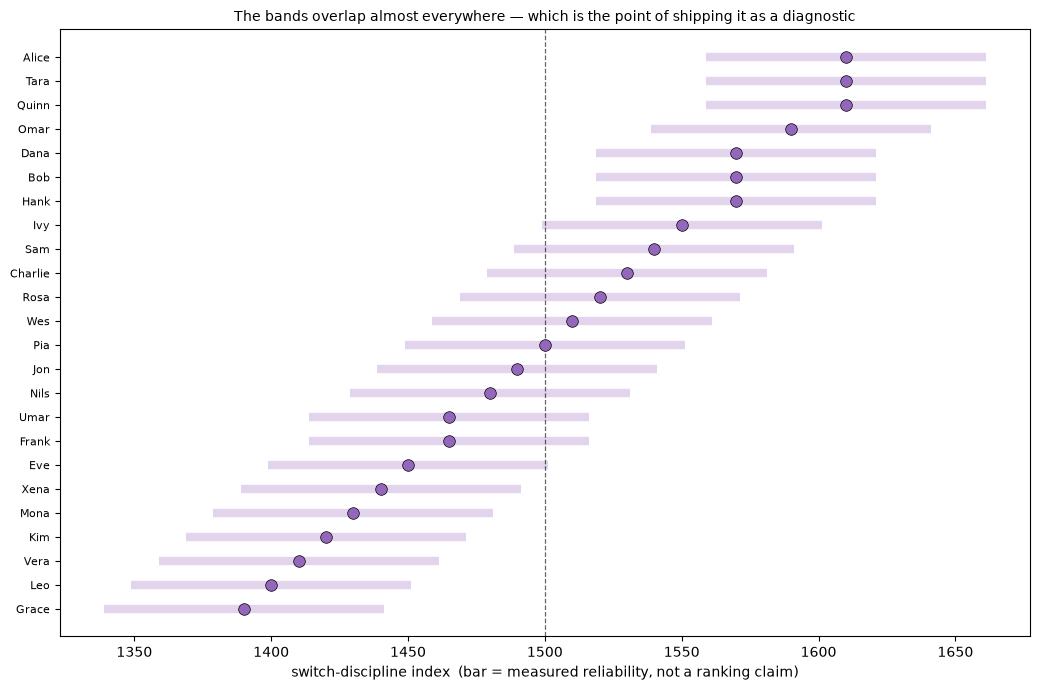

Those bands are wide on purpose. At reliability ~0.57 the ordering within the middle of
the field is not supported by the data, and the chart should not imply that it is.


In [18]:
fig, ax = plt.subplots(figsize=(10.5, 7.0))
order = thinkers.sort_values("discipline_index")
y = np.arange(len(order))
ax.hlines(y, order.band_lo, order.band_hi, color="#9467bd", lw=6, alpha=0.28)
ax.scatter(order.discipline_index, y, s=70, color="#9467bd",
           edgecolor="black", linewidth=0.5, zorder=3)
ax.axvline(1500, color="black", lw=0.9, ls="--", alpha=0.6)
ax.set_yticks(y)
ax.set_yticklabels(order.index, fontsize=8)
ax.set_xlabel("switch-discipline index  (bar = measured reliability, not a ranking claim)")
ax.set_title("The bands overlap almost everywhere — which is the point of shipping it as a diagnostic",
             fontsize=10)
plt.tight_layout()
plt.show()

print("Those bands are wide on purpose. At reliability ~0.57 the ordering within the middle of")
print("the field is not supported by the data, and the chart should not imply that it is.")

---
## 16. Schema and persistence

Thinkers is the only one of the four that requires a change to the **bronze** layer. That is the
part to act on soonest, because history cannot be back-filled.

In [19]:
import os, json

os.makedirs("data", exist_ok=True)
computed_at = datetime.now()

# --- bronze: the new column, on the match fact ---
strategy_events = (world["events"][["player_id", "day", "career_matches_after", "strategy_id"]]
                   .assign(captured_at="match_time")
                   .head(5))

# --- silver: decision points, derived ---
decision_log = (world["decisions"]
                .assign(cohort_id="cohort_2022_2025_all", policy_id="thinkers_v1")
                [["player_id", "career_matches_after", "cohort_id", "policy_id",
                  "observed_form", "in_slump", "switched", "from_strategy", "to_strategy"]])

# --- gold: the diagnostic, carrying its own reliability ---
thinkers_diagnostic = (thinkers.reset_index(names="player_id")
    .assign(cohort_id="cohort_2022_2025_all", policy_id="thinkers_v1", computed_at=computed_at)
    [["player_id", "cohort_id", "policy_id", "computed_at", "discipline", "discipline_index",
      "band_lo", "band_hi", "reliability", "is_rankable", "status",
      "adaptation_value", "adaptation_value_rankable", "n_calm_points", "n_slump_points"]])

thinkers_policies = pd.DataFrame([{
    "policy_id": "thinkers_v1",
    "applies_to": "thinkers",
    "source_tables": "match_events(strategy_id) + overall_rating_events",
    "requires_new_capture": True,
    "convergence_matches": CONVERGENCE_MATCHES,
    "decision_every": DECISION_EVERY,
    "trigger_json": json.dumps({"window": TRIGGER_WINDOW, "level": TRIGGER_LEVEL}),
    "windows_json": json.dumps({"pre": PRE_WINDOW, "post": POST_WINDOW,
                                "min_events": MIN_WINDOW_EVENTS, "min_episodes": MIN_EPISODES}),
    "reliability_bar": RELIABILITY_BAR,
    "ranked_components": json.dumps([]),      # nothing clears the bar yet -- recorded, not implied
    "diagnostic_components": json.dumps(["discipline"]),
    "rejected_components": json.dumps({"adaptation_value": "reliability ~0, flat under 8x data",
                                       "prototype_rule": "tracks switch volume, not quality"}),
    "created_at": computed_at,
}])

for name, df in [("thinkers_decision_log", decision_log),
                 ("thinkers_diagnostic", thinkers_diagnostic),
                 ("thinkers_policies", thinkers_policies)]:
    df.to_csv(f"data/{name}.csv", index=False)
    print(f"data/{name}.csv".ljust(36), f"{len(df):>6} rows")

print("\nbronze requirement -- match_events gains one column, captured at match time:")
strategy_events

data/thinkers_decision_log.csv         1855 rows
data/thinkers_diagnostic.csv             24 rows
data/thinkers_policies.csv                1 rows

bronze requirement -- match_events gains one column, captured at match time:


,player_id,day,career_matches_after,strategy_id,captured_at
0,Omar,0.030,1,1,match_time
1,Vera,0.030,1,3,match_time
2,Dana,0.186,1,3,match_time
3,Nils,0.186,1,2,match_time
4,Xena,0.191,1,3,match_time


Two schema decisions above are doing real work and are easy to skip past:

**`ranked_components` is persisted as an empty list.** The policy row records that nothing cleared
the bar, rather than leaving it implicit. A consumer reading the table can tell the difference
between "we evaluated and nothing qualified" and "nobody has looked at this".

**`rejected_components` records *why*.** This is the part that saves the next person six weeks. The
adaptation estimator is not missing — it was built, validated, and rejected with a reason attached.
Without that, the obvious next idea is to rebuild it.

In [20]:
# Purity check, as in the other notebooks: same log + same policy -> same output.
rebuilt, rebuilt_rel = build_thinkers_diagnostic(world)
print(f"max |rebuild - original| = "
      f"{(rebuilt.discipline_index - thinkers.discipline_index).abs().max():.2e}")
print(f"reliability identical: {rebuilt_rel == measured_reliability}")

max |rebuild - original| = 0.00e+00
reliability identical: True


---
## 17. The four ratings, together

With all four built, the framework the original notebook proposed comes out as **three ratings and
one diagnostic**:

| Rating | Question | Reads from | Status |
|---|---|---|---|
| **Seasonal** | how are you doing *now*? | `match_events` + `season_id` | ranked |
| **Overall** | how strong are you? | `match_events` | ranked |
| **Prosperity** | which way are you going? | `overall_rating_events` | ranked, with a confidence band |
| **Thinkers** | are your decisions good? | `match_events.strategy_id` **(new capture)** | **diagnostic only** |

Each one needed a different trap cleared before it measured anything, and the traps were specific
enough that none of them generalised from the previous notebook:

| Rating | The trap | The fix |
|---|---|---|
| Seasonal | the boundary is the only real design decision | store an append-only event log, not final ratings |
| Overall | "won't old results pollute it forever?" | measure Elo's memory; it is already a forgetting algorithm |
| Prosperity | improvement is mostly convergence from 1500 | a measurement window, plus a field-relative target |
| Thinkers | outcomes after a decision are selected on form | a within-player matched control — which then was not enough |

### What transfers

Four habits, in the order they would have saved the most time:

1. **Run the placebo.** Build the world where the effect is zero and ask the estimator what it
   found. This notebook's central result came from one simulation that could not have been run on
   real data, and it invalidated the prototype rule outright.
2. **Split-half before shipping**, Spearman–Brown corrected. Two of prosperity's candidate
   components and both of Thinkers' failed a test that takes ten lines. Apply the correction —
   uncorrected, `discipline` reads 0.40 and looks hopeless rather than merely early.
3. **Replicate across seeds before believing.** A rank correlation over 24 players has error bars of
   roughly ±0.2. The prosperity notebook shipped a wrong claim because it skipped this.
4. **Plot the power curve before promising.** It is the only way to tell "not enough data yet" from
   "this will never work", and those two answers lead to opposite decisions.

### Next steps for the repo

1. **Add `strategy_id` to match ingestion now.** It is the only item here with a deadline — every
   match played without it is permanently unanalysable. The rating can wait; the capture cannot.
2. `src/thinkers.py` — `switch_discipline`, `adaptation_value`, `build_thinkers_diagnostic`.
   Keep `adaptation_value`: it is the regression test that stops someone re-deriving it
3. `src/reliability.py` — `spearman_brown`, the split-half check and the power curve, shared with
   prosperity and run in CI. A component's `is_rankable` should be **computed**, never configured
4. Re-evaluate Thinkers at **~36 recorded switches per competitor**. Until then the endpoint returns
   the diagnostic with `is_rankable = false`, and clients must render the band
5. `GET /thinkers?cohort_id=` — returns the diagnostic, its reliability, and `status`. There is
   deliberately no `thinkers_rating` field to return yet
6. The remaining honest gap: whether real competitors' decision quality shows up as *restlessness*
   (measurable) or as *choice quality* (not). That is an empirical question about this domain, and
   answering it needs the `strategy_id` history from item 1